# How to use (decorrelation)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

import noisefinder

Generate three time series with known PSDs. The measured ones are included in the vector `meas`. The vector `xres` is the residual, unknown to the algorithm, which we would like to retrieve as a result (its PSD).\
The main timeseries :math:`x` is correlated to :math:`y_1` and :math:`y_2` through the coefficients :math:`\alpha_i=19,0.1`, which we also want to retrieve.

In [2]:
xres = np.cumsum(scipy.stats.norm.rvs(size=210000))+100*scipy.stats.norm.rvs(size=210000)

y1 = 0.5*np.cumsum(scipy.stats.norm.rvs(size=210000))
y2 = 1000*scipy.stats.norm.rvs(size=210000)

alpha1 = 19
alpha2 = 0.10
xdat = xres + alpha1*y1 + alpha2*y2

xres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
y1_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
y2_true = lambda f: 1000*np.sqrt(2/10)*f**0
xdat_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [xdat,y1,y2]

#calculate welch for comparison
PSDfres,PSDvres = scipy.signal.welch(xres,fs=10,window='blackmanharris',nperseg=20000)
PSDfA,PSDvA = scipy.signal.welch(xdat,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = scipy.signal.welch(y1,fs=10,window='blackmanharris',nperseg=20000)
PSDfC,PSDvC = scipy.signal.welch(y2,fs=10,window='blackmanharris',nperseg=20000)

We create an instance of :class:`noisefinder.CPSD_LPFmethod`, as we want to do it with the LPF frequency scheme, for this example.\
We evaluate the PSD quantiles, as we will use them later.

In [3]:
# define frequency scheme
fs = 10
LPF_frscheme = noisefinder.freqscheme_presets.lpfScheme(Lmax=20000, fmax=None, fs=fs)
CPSD_LPF  = noisefinder.cpsd.CPSDevaluate(ts=meas,freqscheme=LPF_frscheme)
ASD_LPF_CI_xdat = noisefinder.cpsd.stats.ASDposterior_qnt(CPSD_LPF,tsidx=0,q=[(1-0.68)/2,0.50,((1+0.68)/2)])

Now, we perform noise projection / decorrelation, with :class:`noisefinder.noiseproj`, and get the residual confidence intervals with :meth:`get_noiseprojCI`.

In [4]:
# now perform noise projection and retrieve residual
mfnp = noisefinder.noiseproj.run_noiseproj(CPSDmat=CPSD_LPF.CPSD,navs=CPSD_LPF.navs)

ASDres_2sigma = noisefinder.noiseproj.stats.ASDresidual_qnt(mfnp,q=[(1-0.95)/2,0.50,((1+0.95)/2)])

alpre_2sigma, alpim_2sigma = noisefinder.noiseproj.stats.alpha_qnt(mfnp,q=[(1-0.95)/2,0.50,((1+0.95)/2)])

Plot the residual ASD, comparing with the expected values.

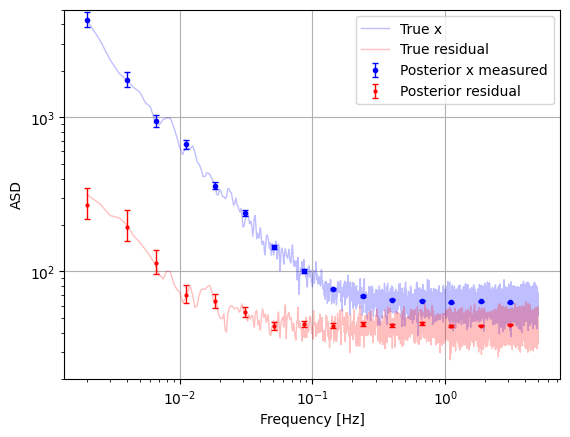

In [5]:
fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='True x',c='b',alpha=0.25)
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='True residual',alpha=0.25)

ax.errorbar(CPSD_LPF.freqs,
            ASD_LPF_CI_xdat[1,:],
            yerr = [ASD_LPF_CI_xdat[1,:]-ASD_LPF_CI_xdat[0,:],
                    ASD_LPF_CI_xdat[2,:]-ASD_LPF_CI_xdat[1,:]],
            linestyle='',capsize=2.5,lw=1,c='b',fmt='.',label='Posterior x measured')

ax.errorbar(CPSD_LPF.freqs,
            ASDres_2sigma[1],
            yerr = [ASDres_2sigma[1]-ASDres_2sigma[0],ASDres_2sigma[2]-ASDres_2sigma[1]],
            linestyle='',capsize=2,lw=1,c='r',fmt='.',markersize=4,label='Posterior residual')

ax.grid(); ax.legend(); ax.set_ylim(2e1,5e3);
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('ASD'); 
plt.show()

And plot the susceptibilities, with their expected values.

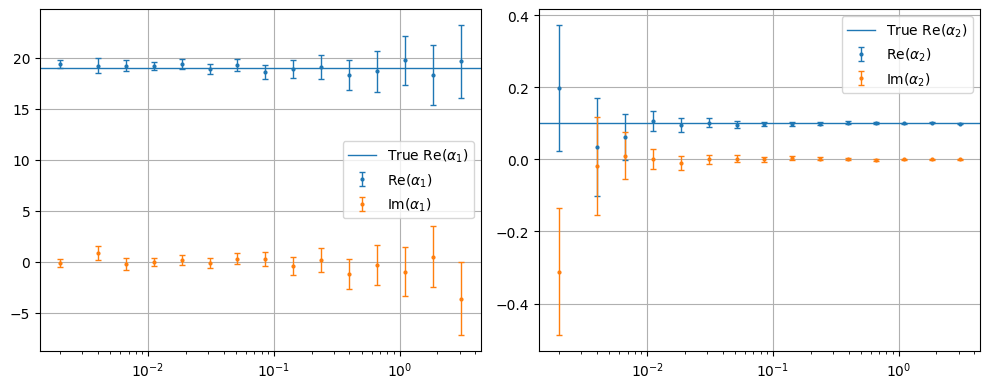

In [6]:
fig,ax=plt.subplots(1,2,figsize=(10,4),sharex=True)

tsidx = 0
ax[0].errorbar(CPSD_LPF.freqs,
            alpre_2sigma[:,tsidx,1],
            yerr = [alpre_2sigma[:,tsidx,1]-alpre_2sigma[:,tsidx,0],alpre_2sigma[:,tsidx,2]-alpre_2sigma[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label=r'Re($\alpha_1$)')
ax[0].axhline(19,c='C0',lw=1,label=r'True Re($\alpha_1$)')
ax[0].errorbar(CPSD_LPF.freqs,
            alpim_2sigma[:,tsidx,1],
            yerr = [alpim_2sigma[:,tsidx,1]-alpim_2sigma[:,tsidx,0],alpim_2sigma[:,tsidx,2]-alpim_2sigma[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label=r'Im($\alpha_1$)')
ax[0].set_xscale('log'); ax[0].grid(); ax[0].legend()

tsidx = 1
ax[1].errorbar(CPSD_LPF.freqs,
            alpre_2sigma[:,tsidx,1],
            yerr = [alpre_2sigma[:,tsidx,1]-alpre_2sigma[:,tsidx,0],alpre_2sigma[:,tsidx,2]-alpre_2sigma[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label=r'Re($\alpha_2$)')
ax[1].axhline(0.1,c='C0',lw=1,label=r'True Re($\alpha_2$)')
ax[1].errorbar(CPSD_LPF.freqs,
            alpim_2sigma[:,tsidx,1],
            yerr = [alpim_2sigma[:,tsidx,1]-alpim_2sigma[:,tsidx,0],alpim_2sigma[:,tsidx,2]-alpim_2sigma[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label=r'Im($\alpha_2$)')
ax[1].set_xscale('log'); ax[1].grid(); ax[1].legend()
fig.tight_layout()
plt.show()